CODE

test commit 2 - Marine
test commit 3 - Mairne 
['MET', 'GLY', 'HIS', 'HIS', 'HIS', 'HIS', 'HIS', 'HIS', 'SER', 'SER', 'GLY', 'VAL', 'ASP', 'LEU', 'GLY', 'THR', 'GLU', 'ASN', 'LEU', 'TYR', 'PHE', 'GLN', 'SER', 'MET', 'ALA', 'SER', 'GLU', 'PHE', 'LYS', 'LYS', 'LYS', 'LEU', 'PHE', 'TRP', 'ARG', 'ALA', 'VAL', 'VAL', 'ALA', 'GLU', 'PHE', 'LEU', 'ALA', 'THR', 'THR', 'LEU', 'PHE', 'VAL', 'PHE', 'ILE', 'SER', 'ILE', 'GLY', 'SER', 'ALA', 'LEU', 'GLY', 'PHE', 'LYS', 'TYR', 'PRO', 'VAL', 'GLY', 'ASN', 'ASN', 'GLN', 'THR', 'ALA', 'VAL', 'GLN', 'ASP', 'ASN', 'VAL', 'LYS', 'VAL', 'SER', 'LEU', 'ALA', 'PHE', 'GLY', 'LEU', 'SER', 'ILE', 'ALA', 'THR', 'LEU', 'ALA', 'GLN', 'SER', 'VAL', 'GLY', 'HIS', 'ILE', 'SER', 'GLY', 'ALA', 'HIS', 'LEU', 'ASN', 'PRO', 'ALA', 'VAL', 'THR', 'LEU', 'GLY', 'LEU', 'LEU', 'LEU', 'SER', 'CYS', 'GLN', 'ILE', 'SER', 'ILE', 'PHE', 'ARG', 'ALA', 'LEU', 'MET', 'TYR', 'ILE', 'ILE', 'ALA', 'GLN', 'CYS', 'VAL', 'GLY', 'ALA', 'ILE', 'VAL', 'ALA', 'THR', 'ALA', 'ILE', 'LEU', 'SER', 

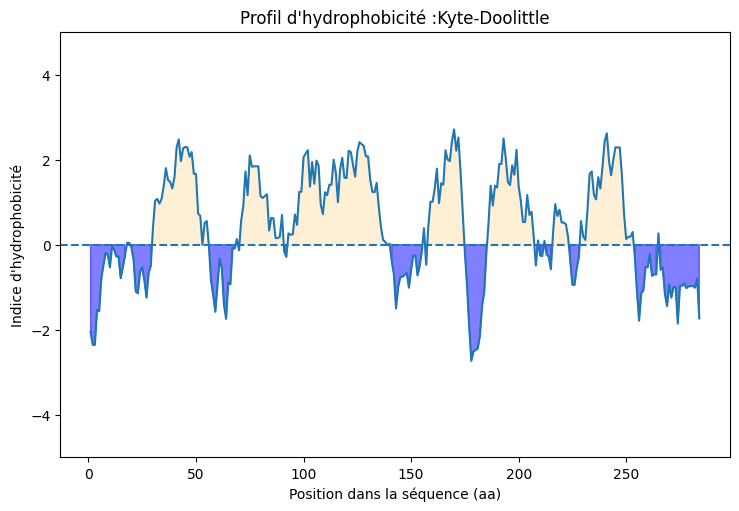

In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

print("test commit 2 - Marine")
print("test commit 3 - Mairne ") #test !


#------------------------Initialisation----------------------------------------------#
global name_tech
name_tech = "Kyte-Doolittle"
ECHELLE_HYDROPHOBE = {
    "Kyte-Doolittle": {
        "ALA":1.8,"ARG":-4.5,"ASN":-3.5,"ASP":-3.5,"CYS":2.5,
        "GLN":-3.5,"GLU":-3.5,"GLY":-0.4,"HIS":-3.2,"ILE":4.5,
        "LEU":3.8,"LYS":-3.9,"MET":1.9,"PHE":2.8,"PRO":-1.6,
        "SER":-0.8,"THR":-0.7,"TRP":-0.9,"TYR":-1.3,"VAL":4.2
    },
        "Hopp-Woods": {
        "ALA":-0.5,"ARG":3,"ASN":0.2,"ASP":3,"CYS":-1,
        "GLN":3,"GLU":0.2,"GLY":0,"HIS":-0.5,"ILE":-1.8,
        "LEU":-1.8,"LYS":3,"MET":-1.3,"PHE":-2.5,"PRO":0,
        "SER":0.3,"THR":-0.4,"TRP":-3.4,"TYR":-2.3,"VAL":-1.5
    }
}


#-------------------------------LECTURE_PDB--------------------------------------#



def lire_sequence_pdb(nom_f):
    indice = ECHELLE_HYDROPHOBE[name_tech]
    seq = []
    g = open(nom_f, "r")
    ligne = g.readline()
    while ligne != "":
        if ligne[0:6] == "SEQRES":
            long_seq = ligne[19:]
            i = 0
            while i < len(long_seq):
                aa = long_seq[i:i+3]
                i += 4
                if aa in indice:
                    seq += [aa]
        ligne = g.readline()
    g.close()
    print(seq)
    return(seq)

#---------------------------Programme-------------------------------------------#

def moyenne_hydrophobe(seq, fenetre):
    '''Prend un taille de fenetre, un dictionnaire contenant les acides aminés et leur indice d'hydrophobicité ainsi qu'une seq d'aa pour:
    -Pour chaque aa: regardé autour de celui ci (en fonction de la taille de la fenêtre) et faire la moyenne des indices des aa autour
    -Créer une liste de coordonées x,y qu'il renverra
    -profite pour compter les aa et rajouter un 0 à chaque fois pour tracer à la fin la ligne de délimitation'''
    y= [] #listes des coordonées
    indice = ECHELLE_HYDROPHOBE[name_tech]
    demi_f = (fenetre-1)//2
    position_central = demi_f #un coté de la fenetre (gauche)
    while position_central < len(seq)-demi_f: # coté droit, Pour chaque acide aminé
        i = 0
        #if seq[position_central] == "HIS":
            #print("AHA", position_central)
            #zone_graphe.scatter(position_central, 0, color="red", s=10) Verifier où est l'histidine (enlever le clear)
        moyenne = 0
        while i < fenetre and position_central-demi_f+i < len(seq) : 
            #print(position_central, demi_f, i, len(seq))
            if seq[position_central-demi_f+i] not in indice: #Vérifie que l'aa existe
                i +=1
            else:
                moyenne += indice.get(seq[position_central-demi_f+i]) #va additionner les aa à droite et à gauche de notre aa principal (si fenentre = 9, on aura 4aa à droite et 4 aa à gauche)
                #print(seq[k-((fenetre-1)//2)+i], ":", indice.get(seq[k-((fenetre-1)//2)+i]))
                i +=1
        moyenne = moyenne / fenetre #Calcul la moyenne des aa

        #création d'une liste comprenant toutes les coordonées des aa avec leur moyenne d'indice d'hydrophobicité
        y += [moyenne]
        #print("moyenne:", moyenne,"k:", seq[k])
        position_central += 1
    
    return y
# -------- TRAITEMENT DES ERREURS --------#
def test_erreur(taille_fenetre, sequence):
    '''Vérifie si la taille de la fenetre entré est bonne ou non'''
    if len(sequence) == 0:
        messagebox.showerror("Erreur 01", "Aucune séquence trouvée")
        return True
    
    v = 0
    while v < len(str(taille_fenetre)):
        if str(taille_fenetre)[v] not in ["1","2","3","4","5","6","7","8","9","0"]:
            messagebox.showerror("Erreur 02", "caractère non autorisé dans la taille de fenetre")
            return True
        v += 1
    if taille_fenetre == "":
        messagebox.showerror("Erreur 03", "Rentrez avant une taille de fenetre")
        return True
    elif int(taille_fenetre) == 0 or int(taille_fenetre) > len(sequence):
        messagebox.showerror("Erreur 04", "Taille de la fenetre non conforme")
        return True
    return False

#-----------------Tutoriel-------------------#
def tutoriel():
    Choix = tk.messagebox.askyesno ( title = "Tuto" , message = "Voulez vous un court tutoriel?" )
    if Choix:
        messagebox.showinfo(title = "Introduction", message="Bienvenue dans ... pour vous aider à prédire les régions hydrophobes d'une protéine à partir d'un fichier PDB !")
        messagebox.showinfo(title = "Introduction", message="Pour commencer, choisissez une technique (Kyte-Doolittle ou Hopp-Woods)")
        messagebox.showinfo(title = "Introduction", message="Puis choisissez la taille de la fenêtre")
        messagebox.showinfo(title = "Introduction", message="Enfin choisissez un fichier PDB et le tour est joué !")
        Choix1 = tk.messagebox.askyesno ( title = "interprétation" , message = "Voulez vous savoir rapidement comment interpréter le résultat ?" )
        if Choix1:
            messagebox.showinfo(title = "interprétation",message="Très bien, l'interprétation sera différente entre les deux techniques proposées.")
            messagebox.showinfo(title = "interprétation Kyte and Doolittle",message="Pour Kyte and Doolittle, les régions hydrophobes seront au dessus de la ligne, et en dessous les régions hydrophiles. Pour detecter les régions transmembranaires, une fenêtre assez large est recommandée (environ 20)")
            messagebox.showinfo(title = "interprétation Hopp and Woods",message="Pour Hopp and Woods, c'est l'inverse, les régions hydrophobes se trouvent en dessous de la ligne. Pour detecter des régions antigéniques une taille de fenetre d'environ 7 est recommandée.")

# -------- GRAPHIQUE --------#
def afficher_profil_hydrophobicite(profil):
    zone_graphe.clear()

    positions_seq = list(range(1, len(profil) + 1))
    valeurs = np.array(profil)

    zone_graphe.plot(positions_seq, valeurs)
    zone_graphe.axhline(0, linestyle="--")

    zone_graphe.fill_between(positions_seq, valeurs, 0, where=(valeurs >= 0), color  = "papayawhip",alpha=1)
    zone_graphe.fill_between(positions_seq, valeurs, 0, where=(valeurs < 0),color = "blue", alpha=0.5)
    

    #Adapte l'echelle de la fenetre
    if len(profil)<120:
        zone_graphe.set_xticks(range(0, len(profil) + 1, 10))
    elif len(profil) <250:
        zone_graphe.set_xticks(range(0, len(profil) + 1, 20))
    elif len(profil) <400 :
        zone_graphe.set_xticks(range(0, len(profil) + 1, 50))
    elif len(profil)<1000 :
        zone_graphe.set_xticks(range(0, len(profil) + 1, 100))
    elif len(profil)< 1500:
        zone_graphe.set_xticks(range(0, len(profil) + 1, 200))
    elif len(profil)<2000:
        zone_graphe.set_xticks(range(0, len(profil) + 1, 400))
        

    zone_graphe.set_ylim(-5, 5)
    zone_graphe.set_title("Profil d'hydrophobicité: " + name_tech)
    zone_graphe.set_xlabel("Position dans la séquence (aa)")
    zone_graphe.set_ylabel("Indice d'hydrophobicité")

    canvas_graphique.draw()

# -------- ACTION BOUTON --------

def charger_fichier_pdb():
    chemin_fichier = filedialog.askopenfilename(title="Choisir un fichier PDB",filetypes=[("Fichiers PDB", "*.pdb")])
    taille_fenetre=fenetre_var.get() #Pour l'instant je ne sais pas si c'est un int ou un str etc...
    if not chemin_fichier:
        return

    sequence = lire_sequence_pdb(chemin_fichier)

    if test_erreur(taille_fenetre, sequence):
        return
    taille_fenetre=int(taille_fenetre)

    label_information.config(text="Longueur : " + str(len(sequence)))

    profil = moyenne_hydrophobe(sequence, taille_fenetre)
    afficher_profil_hydrophobicite(profil)





# -------- INTERFACE --------

fenetre_principale = tk.Tk()
fenetre_principale.geometry("700x600")
fenetre_principale.title("Profil d'hydrophobicité")
fenetre_principale.iconbitmap("logo.ico")
fenetre_principale.configure(bg = "maroon")

# grille
i = 0
while i < 20:
    fenetre_principale.grid_rowconfigure(i, weight=1)
    fenetre_principale.grid_columnconfigure(i, weight=1)
    i = i + 1

#bouton de chargement
bouton_chargement = tk.Button(
    fenetre_principale,
    text="Choisir fichier PDB",
    command=charger_fichier_pdb,
    bg = "light grey",
    fg = "blue"
)
bouton_chargement.grid(row=0, column=10, columnspan=3, sticky="nsew") 

#Label
label_information = tk.Label(fenetre_principale, text="Longueur : ", borderwidth=5, relief = "solid",bg="light grey",fg="red")
label_information.grid(row=1, column=2, columnspan=3)

#graphe
figure_graphique, zone_graphe = plt.subplots(figsize=(4, 3))

canvas_graphique = FigureCanvasTkAgg(figure_graphique, master=fenetre_principale)
canvas_graphique.get_tk_widget().grid(row=10,column=5,columnspan=8,rowspan=8,sticky="snew")

#Input pour taille de fenetre
fenetre_var=tk.StringVar()
fenetre_entry = tk.Entry(fenetre_principale,textvariable = fenetre_var)
fenetre_entry.grid(row=0,column=1)

#Label pour taille de fenetre
label_fenetre = tk.Label(fenetre_principale, text="Taille de fenetre : ",bg="red")
label_fenetre.grid(row=0, column=0)






# Création d'un menu défilant
def changement_k():#Fonction appellé si K&D choisit
    global name_tech
    name_tech = "Kyte-Doolittle"
    name_button_tech.set("Technique: Kyte-Doolittle")
    #print(name_tech)
def changement_h():#Fonction appellé si Hopp-Woods choisit
    global name_tech
    name_tech = "Hopp-Woods"
    name_button_tech.set("Technique: Hopp-Woods")
    #print(name_tech)

#Bouton technique

name_button_tech = tk.StringVar() #variable pour changer son nom
name_button_tech.set("Technique: Kyte-Doolittle") #Par défaut
bouttonTech = tk.Menubutton(fenetre_principale, textvariable = name_button_tech) #boutton technique

bouttonTech.grid(row=2, column=0) #Positionnement du bouton technique

menuAffichage = tk.Menu(bouttonTech, tearoff = 0) #Configure menu déroulant

#Ajout des différentes techniques dans le menu déroulant
menuAffichage.add_command(label='K&D', command=changement_k)
menuAffichage.add_command(label="Hopp-Woods", command=changement_h)
tutoriel() #Propose un tutoriel

bouttonTech.configure(menu=menuAffichage) #Créer le menu déroulant avec menuAffichage sur le bouton bouttonTech
fenetre_principale.mainloop()